In [1]:
import pandas as pd
import networkx as nx

data = 'data/gsv3/gsv3_entity_collaboration.csv'

In [2]:
df = pd.read_csv(data)
df.head()

,source,target,date
0,Tipsy Scoop,Tipsy Scoop Queens,2023-10-08
1,Tipsy Scoop,Tipsy Scoop Queens,2024-01-25
2,Tipsy Scoop,Tipsy Scoop Queens,2026-01-14
3,Nico,Derrick Carter,2024-02-15
4,Nico,Derrick Carter,2026-01-08


In [8]:
df.shape

(268598, 3)

In [9]:
G = nx.from_pandas_edgelist(df)

In [10]:
print(G)

Graph with 22759 nodes and 116846 edges


# Page Rank
This is an indicators of importance, but they are really more of an indication of popularity. Often the lesser known nodes may be what you are actually looking for.

Today, nodes with high values will be popular, active, or influential.

Nodes with lower values will be less popular, but they may also be active and influential in their local ecosystems.

So, don't take centralities as synonyms for importance. They are simply measures that you can use, for understanding.

This shows a weakness of any search engines that prioritize popularity over relevance. Graphs can show pupularity. NLP can help identify relevancy. Graph and NLP together can be especially informative and powerful.

In [36]:
score_df = pd.DataFrame([nx.pagerank(G)]).T
score_df.columns = ['score']
score_df.sort_values('score', ascending=False, inplace=True)
score_df

,score
Night Club 101,0.001342
Tractor,0.001308
Brooklyn Comedy Collective,0.001290
Belly Up,0.001205
Star Theater,0.001082
...,...
The Vine at Del Lago Resort and Casino,0.000008
Preserving Underground,0.000008
Chris Botti Concert,0.000007
Terence Blanchard & Ravi Coltrane,0.000007


In [37]:
# # Simpler Algorithm to explore
# score_df = pd.DataFrame([nx.degree_centrality(G)]).T
# score_df.columns = ['score']
# score_df.sort_values('score', ascending=False, inplace=True)
# score_df

In [38]:
# the labels I want to use
labels_wanted = ['D', 'C', 'B', 'A', 'S']

# count of labels wanted
desired_q = len(labels_wanted)

score_df['class'] = pd.qcut(score_df['score'], q=desired_q, duplicates='drop')

# get the actual number of bins created; in case less than q
n_bins = score_df['class'].nunique()

# add the labels
score_df['class'] = pd.qcut(score_df['score'], q=desired_q, labels=labels_wanted, duplicates='drop')

score_df['class'].value_counts().sort_index()

class
D    4558
C    4549
B    7698
A    1407
S    4547
Name: count, dtype: int64

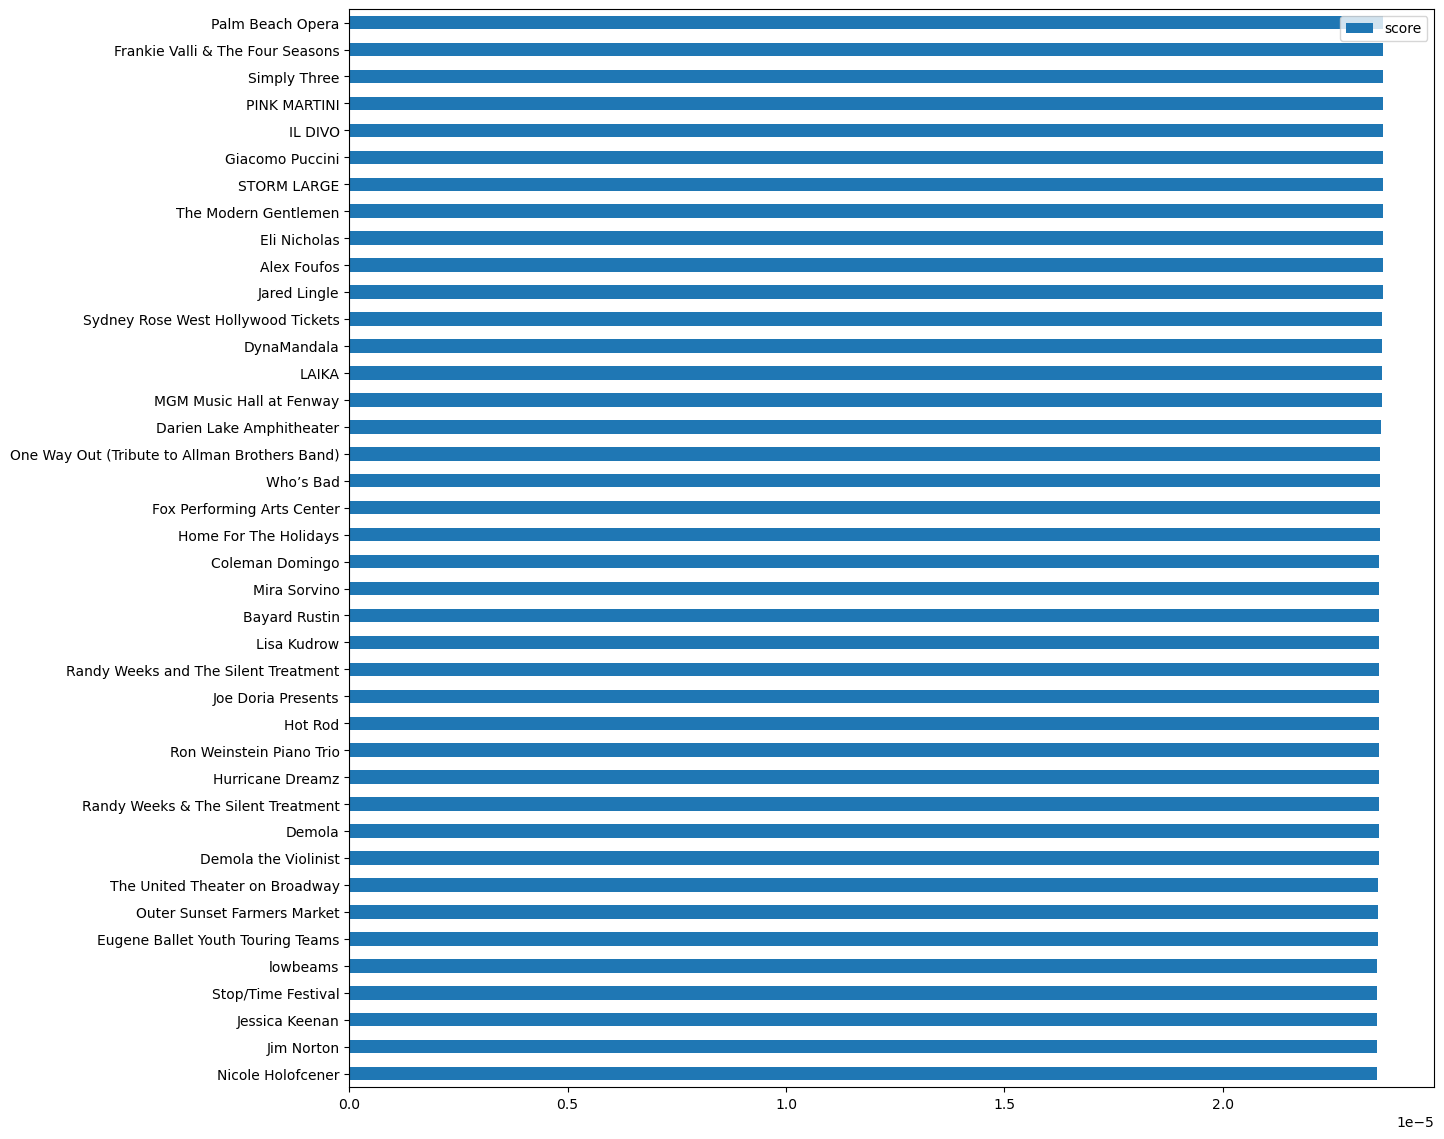

In [39]:
check_df = score_df[score_df['class']=='D']
check_df.head(40).plot.barh(figsize=(14, 14)).invert_yaxis()

Entity: Cosmic Gate Perspectives Album Tour

Related Entities:
- Audien
- Boogie T
- Eliminate
- Ghengar
- Kevin de Vries
- Midnight Tyrannosaurus
- RayBurger
- Rayburger



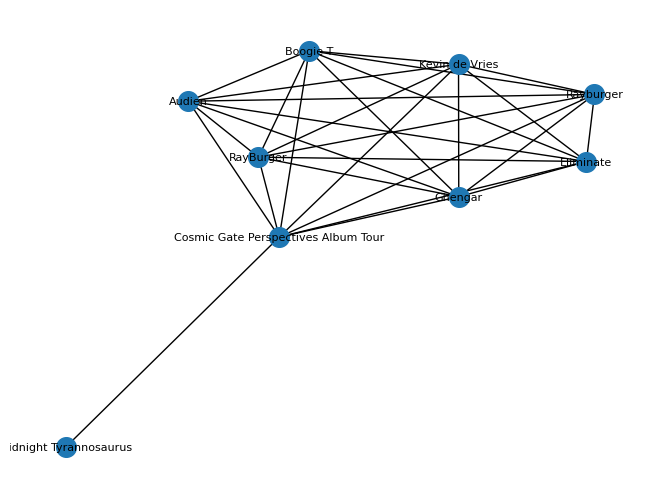

In [48]:
check_df = score_df[score_df['class']=='C'] # LOAD CLASS NODES

entity = check_df.sample(1).index.values[0] # LOAD A RANDOM NODE

ego = nx.ego_graph(G, entity) # CAPTURE ITS EGO GRAPH


related_entities = sorted(ego.nodes) # SEE THE NODES AS TEXT

related_entities = [e for e in related_entities if e is not entity]

print('Entity: {}'.format(entity))
print()
print('Related Entities:')

for related_entity in related_entities:
    print('- {}'.format(related_entity))
#print(related_entities) 


nx.draw_spring(ego, with_labels=True, node_size=200, font_size=8) # DRAW IT

print() 